## Payment Failure Reason Classification

**Project Overview**

Digital payment platforms process millions of transactions every day. When a transaction fails, the
failure may occur for different reasons such as insufficient funds, bank server outages, incorrect
authentication, network instability, fraud risk triggers, or merchant configuration errors. In many real
systems, users only see a generic message such as “Transaction Failed”. However, payment
companies and financial institutions need to understand the exact reason for failure in order to
improve user experience, reduce operational costs, and route issues to the correct operational
teams. In this project, students will build a multi■class classification model that predicts the most
likely reason for a payment failure using transaction metadata, device telemetry, network signals,
and behavioral indicators.

---

**Problem Statement**

Given a dataset of failed payment transactions, build a machine learning model that predicts the
single most likely failure reason for each transaction. Each record belongs to exactly one class
representing the root cause of the failure.

---

**Target Classes**

Failure Classes

INSUFFICIENT_FUNDS

BANK_SERVER_DOWN

PIN_OR_OTP_FAILED

LIMIT_EXCEEDED

NETWORK_TIMEOUT

SUSPECTED_FRAUD

INVALID_VPA_OR_CARD

MERCHANT_CONFIGURATION_ISSUE

---

**Data Dictionary**

**Column**              **Description**

**txn_id** Unique transaction identifier

**user_id** Unique identifier for the user initiating payment

**merchant_id** Unique identifier for merchant receiving payment

**payment_method** Type of payment used (UPI, Card, Wallet)amount Transaction amount

**merchant_category** Business category of the merchant

**is_international** Flag indicating international transaction

**payer_bank** Bank of the payer

**payee_bank** Bank of the receiver

**issuer_type** Type of issuing institution

**device_type** Device used for transaction

**os_version_major** Operating system version of device

**app_version_major** Payment application version

**is_rooted_or_jailbroken** Device security indicator

**sim_operator** Mobile network operator

**network_type** Connection type such as WIFI or mobile data

**latency_ms** Network latency in milliseconds

**packet_loss_pct** Network packet loss percentage

**signal_strength_dbm** Mobile signal strength

**avg_txn_amount_30d** Average transaction amount over last 30 days

**txn_count_24h** Number of transactions performed in last 24 hours

**failed_txn_count_1h** Number of failed attempts in last hour

**chargeback_flag_180d** Chargeback history indicator

**account_age_days** Age of user account

**daily_limit_remaining** Remaining transaction limit for the day

**available_balance_est** Estimated available balance

**velocity_score** Indicator of transaction burst activity

**risk_score** Fraud risk score

**geo_distance_km_from_usual** Distance from typical transaction location

**txn_hour** Hour of transaction

**day_of_week** Day of week

**is_night_txn** Indicator for night transactions

**merchant_failure_rate_1h** Failure rate for merchant in last hour

**bank_failure_rate_1h** Failure rate for bank in last hour

**failure_reason** Target variable representing failure class

---

**Step 1: Exploratory Data Analysis (EDA)**

Students must perform detailed exploratory analysis of the dataset. Tasks include:

- Understand dataset structure and feature types

- Identify missing values and data quality issues

- Study distributions of numerical variables

- Study distributions of categorical variables

- Explore relationships between variables

-  Analyze class distribution of the target variable

-  Identify outliers or unusual patterns

-  Generate visualizations to support findings Every visualization must include a written interpretation explaining the observed pattern and its potential significance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Downloads/payment_failures_multiclass.csv");

In [3]:
df.head()

,txn_id,user_id,merchant_id,payment_method,amount,merchant_category,is_international,payer_bank,payee_bank,issuer_type,...,available_balance_est,velocity_score,risk_score,geo_distance_km_from_usual,txn_hour,day_of_week,is_night_txn,merchant_failure_rate_1h,bank_failure_rate_1h,failure_reason
0,T1000000,61646,5244,UPI,56.80,BILLS,0,ICICI,SBI,PUBLIC,...,356.28,30.3,0.3,8.79,10,2,0,0.0816,0.0384,MERCHANT_CONFIGURATION_ISSUE
1,T1000001,37475,2649,UPI,145.74,BILLS,0,ICICI,SBI,PRIVATE,...,486.26,34.2,29.3,9.27,15,6,0,0.0416,0.0120,INSUFFICIENT_FUNDS
2,T1000002,92086,6755,UPI,364.05,ECOM,0,HDFC,IDFC,PRIVATE,...,125.83,63.9,20.0,2.50,0,1,1,0.0165,0.0213,INSUFFICIENT_FUNDS
3,T1000003,57891,3227,UPI,75.31,TRAVEL,0,SBI,KOTAK,PRIVATE,...,117.73,22.4,11.9,7.88,11,4,0,0.0328,0.0882,BANK_SERVER_DOWN
4,T1000004,18513,7786,UPI,91.36,FUEL,0,PNB,KOTAK,COOP,...,189.28,52.3,20.2,3.22,0,5,1,0.0570,0.0107,INSUFFICIENT_FUNDS


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   txn_id                      25000 non-null  object 
 1   user_id                     25000 non-null  int64  
 2   merchant_id                 25000 non-null  int64  
 3   payment_method              25000 non-null  object 
 4   amount                      25000 non-null  float64
 5   merchant_category           25000 non-null  object 
 6   is_international            25000 non-null  int64  
 7   payer_bank                  25000 non-null  object 
 8   payee_bank                  25000 non-null  object 
 9   issuer_type                 25000 non-null  object 
 10  device_type                 25000 non-null  object 
 11  os_version_major            25000 non-null  int64  
 12  app_version_major           25000 non-null  int64  
 13  is_rooted_or_jailbroken     250

In [5]:
df.shape

(25000, 35)

In [6]:
df.describe()

,user_id,merchant_id,amount,is_international,os_version_major,app_version_major,is_rooted_or_jailbroken,latency_ms,packet_loss_pct,signal_strength_dbm,...,daily_limit_remaining,available_balance_est,velocity_score,risk_score,geo_distance_km_from_usual,txn_hour,day_of_week,is_night_txn,merchant_failure_rate_1h,bank_failure_rate_1h
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000
mean,54931.111560,5471.492040,208.588582,0.018640,11.19328,11.496360,0.049240,132.00076,1.459400,-85.671320,...,46403.099839,346.854589,36.535336,21.573308,6.093216,11.38364,3.004960,0.378560,0.047595,0.051800
std,25944.479021,2599.157495,164.958573,0.135253,3.24146,2.992742,0.216373,73.72831,1.079037,10.365141,...,10539.268932,327.983667,14.677885,11.270724,8.214253,6.90984,1.994205,0.485038,0.037181,0.039936
min,10001.000000,1000.000000,10.000000,0.000000,0.00000,3.000000,0.000000,20.00000,0.000000,-120.000000,...,0.000000,0.000000,0.000000,0.000000,0.090000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,32628.000000,3200.750000,101.190000,0.000000,9.00000,9.000000,0.000000,78.00000,0.660000,-93.000000,...,39245.497500,146.647500,26.400000,13.900000,1.890000,5.00000,1.000000,0.000000,0.019600,0.022100
50%,54869.000000,5454.000000,163.270000,0.000000,12.00000,12.000000,0.000000,122.00000,1.200000,-86.000000,...,47290.830000,251.935000,36.100000,20.100000,3.680000,11.00000,3.000000,0.000000,0.038700,0.041900
75%,77545.500000,7745.000000,261.612500,0.000000,13.00000,14.000000,0.000000,175.00000,1.990000,-79.000000,...,55365.185000,437.132500,46.300000,27.500000,7.170000,17.00000,5.000000,1.000000,0.065700,0.071200
max,99992.000000,9998.000000,2827.440000,1.000000,17.00000,20.000000,1.000000,525.00000,10.000000,-50.000000,...,60000.000000,5618.210000,97.900000,93.000000,282.710000,23.00000,6.000000,1.000000,0.279300,0.355400


In [7]:
df.isnull()

,txn_id,user_id,merchant_id,payment_method,amount,merchant_category,is_international,payer_bank,payee_bank,issuer_type,...,available_balance_est,velocity_score,risk_score,geo_distance_km_from_usual,txn_hour,day_of_week,is_night_txn,merchant_failure_rate_1h,bank_failure_rate_1h,failure_reason
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
24996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
24997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
24998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

txn_id                        0
user_id                       0
merchant_id                   0
payment_method                0
amount                        0
merchant_category             0
is_international              0
payer_bank                    0
payee_bank                    0
issuer_type                   0
device_type                   0
os_version_major              0
app_version_major             0
is_rooted_or_jailbroken       0
sim_operator                  0
network_type                  0
latency_ms                    0
packet_loss_pct               0
signal_strength_dbm           0
avg_txn_amount_30d            0
txn_count_24h                 0
failed_txn_count_1h           0
chargeback_flag_180d          0
account_age_days              0
daily_limit_remaining         0
available_balance_est         0
velocity_score                0
risk_score                    0
geo_distance_km_from_usual    0
txn_hour                      0
day_of_week                   0
is_night

**Histogram plot**

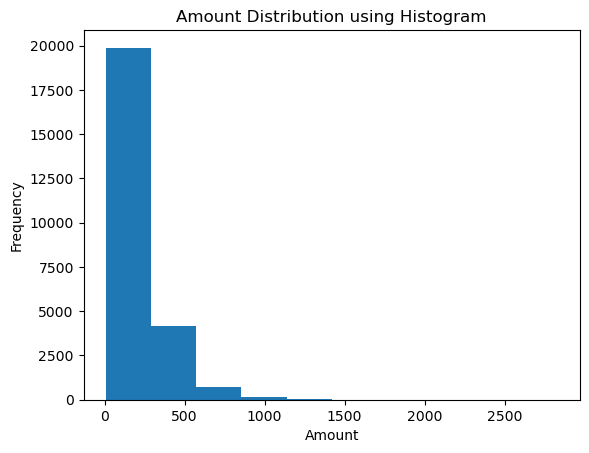

In [9]:
plt.hist(df["amount"])
plt.title("Amount Distribution using Histogram")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

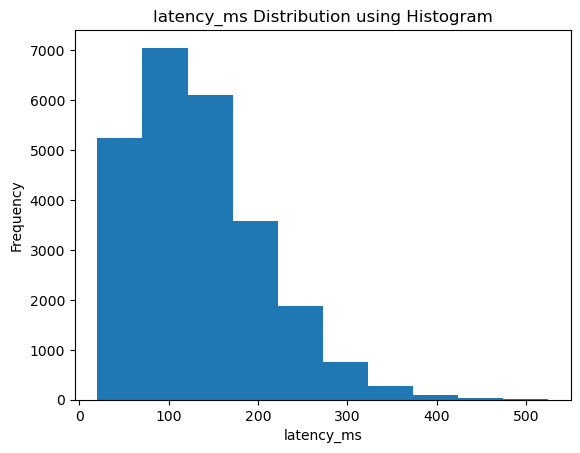

In [10]:
plt.hist(df["latency_ms"])
plt.title("latency_ms Distribution using Histogram")
plt.xlabel("latency_ms")
plt.ylabel("Frequency")
plt.show()

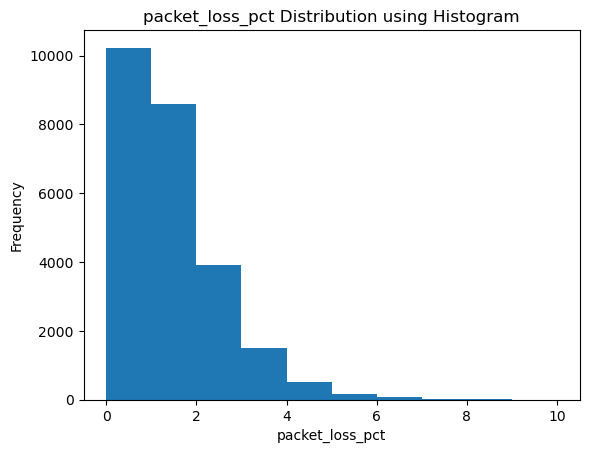

In [11]:
plt.hist(df["packet_loss_pct"])
plt.title("packet_loss_pct Distribution using Histogram")
plt.xlabel("packet_loss_pct")
plt.ylabel("Frequency")
plt.show()

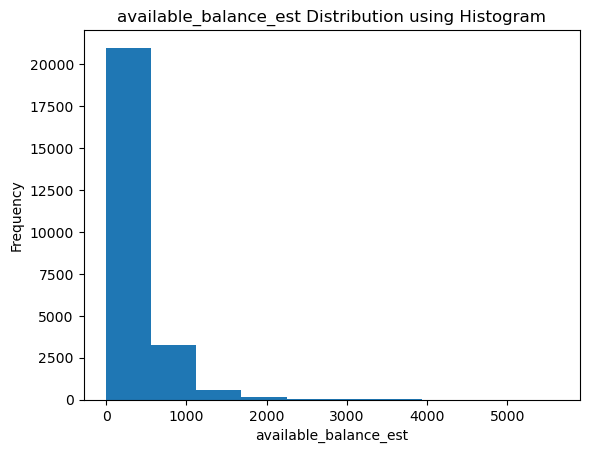

In [12]:
plt.hist(df["available_balance_est"])
plt.title("available_balance_est Distribution using Histogram")
plt.xlabel("available_balance_est")
plt.ylabel("Frequency")
plt.show()

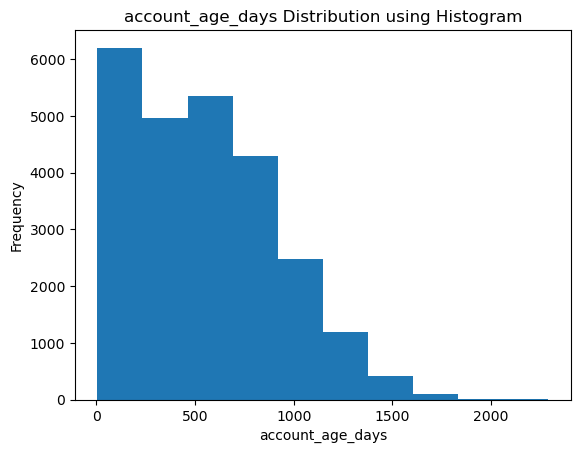

In [13]:
plt.hist(df["account_age_days"])
plt.title("account_age_days Distribution using Histogram")
plt.xlabel("account_age_days")
plt.ylabel("Frequency")
plt.show()

**Count plot**

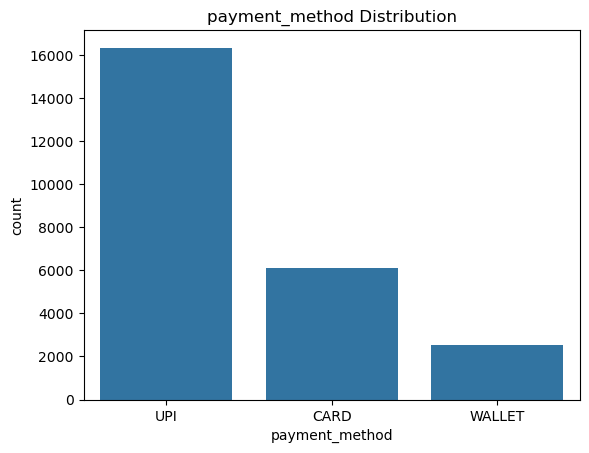

In [14]:
sns.countplot(x='payment_method', data=df)
plt.title("payment_method Distribution")
plt.show()

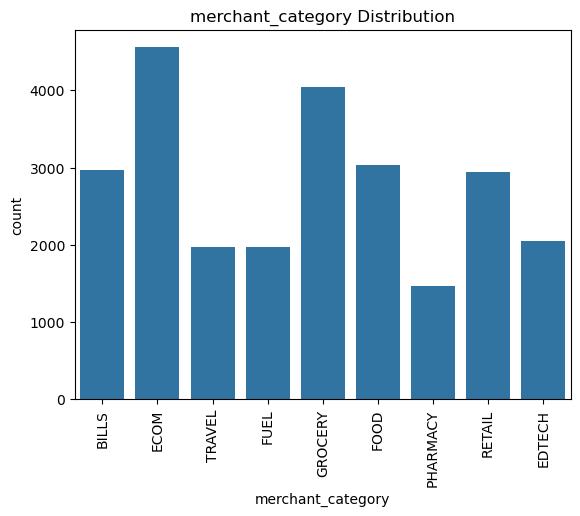

In [15]:
sns.countplot(x='merchant_category', data=df)
plt.title("merchant_category Distribution")
plt.xticks(rotation=90)
plt.show()

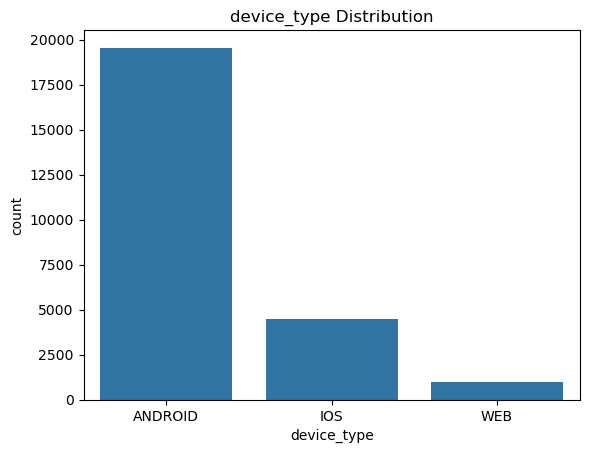

In [16]:
sns.countplot(x='device_type', data=df)
plt.title("device_type Distribution")
plt.show()

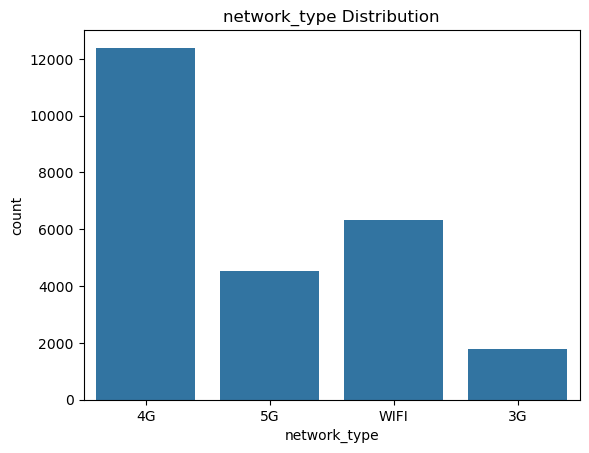

In [17]:
sns.countplot(x='network_type', data=df)
plt.title("network_type Distribution")
plt.show()

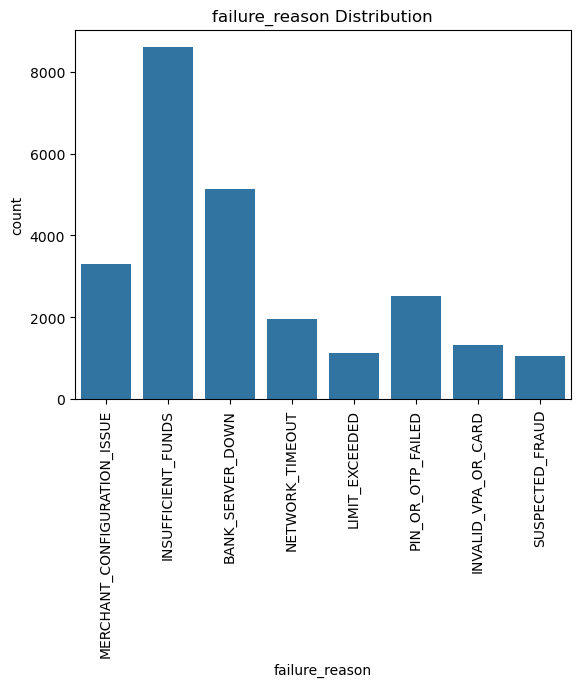

In [18]:
sns.countplot(x='failure_reason', data=df)
plt.title("failure_reason Distribution")
plt.xticks(rotation=90)
plt.show()

**Box plot**

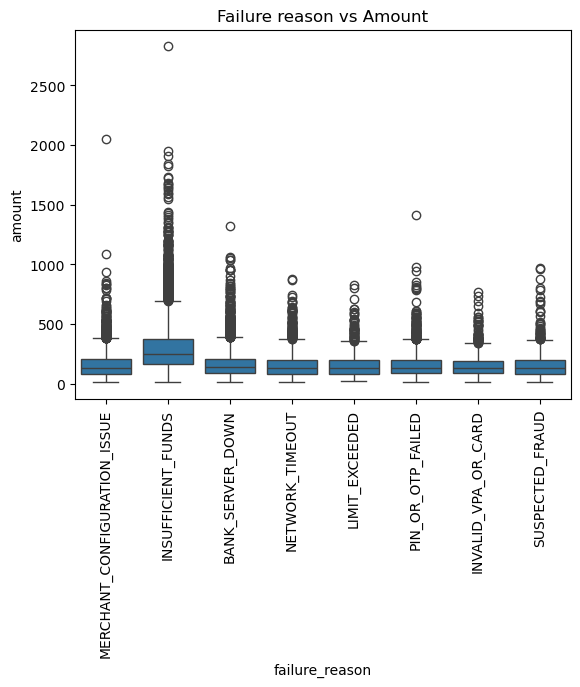

In [19]:
sns.boxplot(x='failure_reason', y='amount', data=df)
plt.title("Failure reason vs Amount")
plt.xticks(rotation=90)
plt.show()

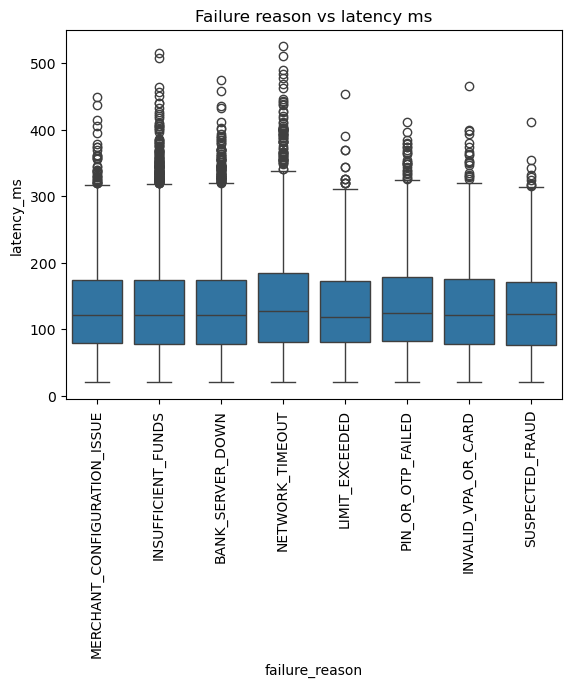

In [20]:
sns.boxplot(x='failure_reason', y='latency_ms', data=df)
plt.title("Failure reason vs latency ms")
plt.xticks(rotation=90)
plt.show()

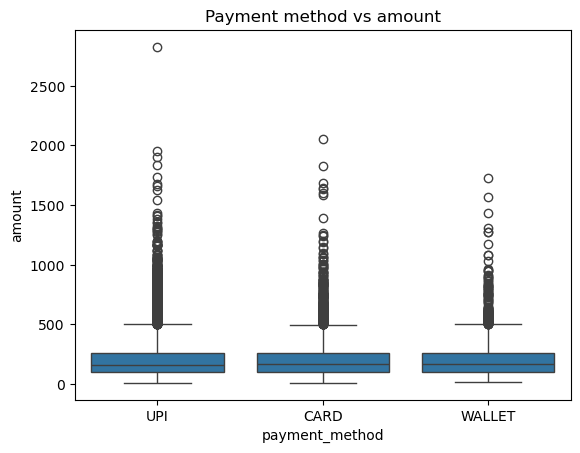

In [21]:
sns.boxplot(x='payment_method', y='amount', data=df)
plt.title("Payment method vs amount")
plt.show()

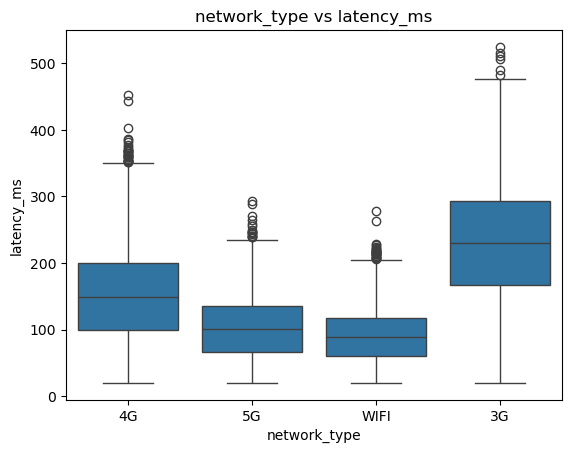

In [22]:
sns.boxplot(x='network_type', y='latency_ms', data=df)
plt.title("network_type vs latency_ms")
plt.show()

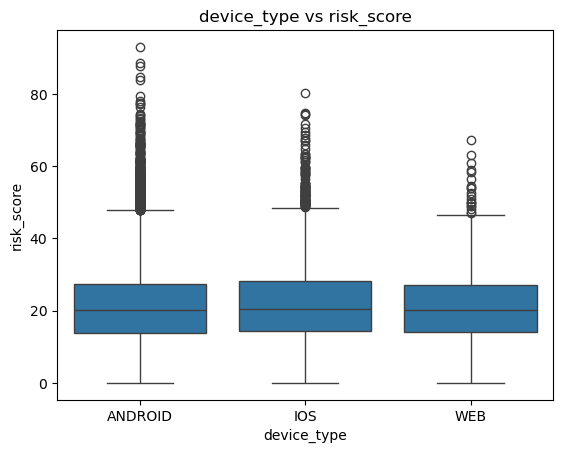

In [23]:
sns.boxplot(x='device_type', y='risk_score', data=df)
plt.title("device_type vs risk_score")
plt.show()

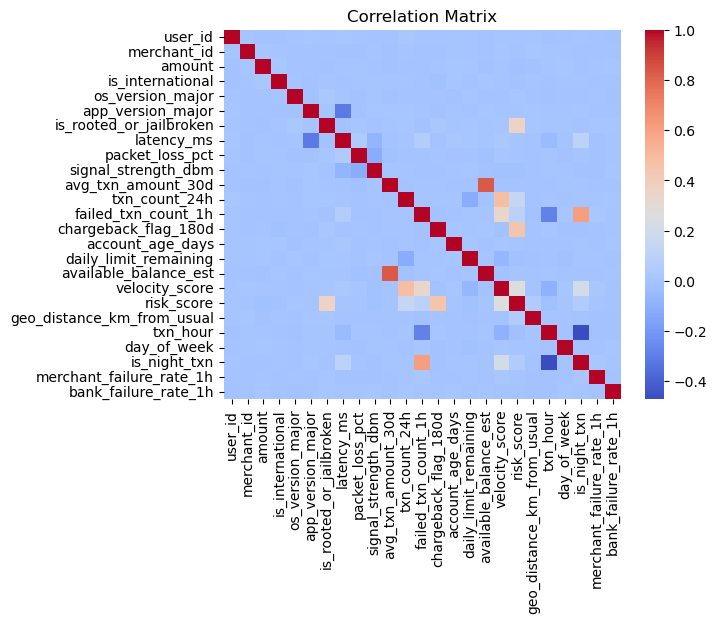

In [24]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Step 2: Feature Engineering**

Students should evaluate whether new variables can improve predictive power. Possible tasks: 

-Derive features from time variables 

-Create behavioral metrics using transaction activity

-Transform skewed variables using log transformation

-Create interaction features if meaningful All engineered features must be justified logically.

In [25]:
def time_of_day(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df["time_of_day"] = df["txn_hour"].apply(time_of_day)

In [26]:
df["time_of_day"]

0          Morning
1        Afternoon
2            Night
3          Morning
4            Night
           ...    
24995        Night
24996      Morning
24997    Afternoon
24998    Afternoon
24999    Afternoon
Name: time_of_day, Length: 25000, dtype: object

Transactions at night may have higher fraud risk.

In [27]:
df[df["amount"] > 5000]

,txn_id,user_id,merchant_id,payment_method,amount,merchant_category,is_international,payer_bank,payee_bank,issuer_type,...,velocity_score,risk_score,geo_distance_km_from_usual,txn_hour,day_of_week,is_night_txn,merchant_failure_rate_1h,bank_failure_rate_1h,failure_reason,time_of_day


In [28]:
df["network_quality"]=df["signal_strength_dbm"] - df["latency_ms"]
df["network_quality"]

0       -189
1       -184
2       -326
3       -228
4       -189
        ... 
24995   -275
24996   -106
24997   -194
24998   -150
24999   -324
Name: network_quality, Length: 25000, dtype: int64

Low network quality may cause NETWORK_TIMEOUT failures.

In [29]:
df["txn_activity"] = df["txn_count_24h"] / 24
df["txn_activity"]

0        0.083333
1        0.000000
2        0.208333
3        0.125000
4        0.083333
           ...   
24995    0.166667
24996    0.083333
24997    0.166667
24998    0.083333
24999    0.041667
Name: txn_activity, Length: 25000, dtype: float64

High transaction activity may indicate suspicious behavior.It can help identify SUSPECTED_FRAUD failures.

**Step 3: Encoding and Scaling**

Machine learning models require numerical input. Students should:

- Encode categorical variables using suitable encoding methods

- Evaluate whether scaling is required for numerical variables

- Apply scaling techniques when necessary depending on the chosen model

**Encoding**

In [30]:
df1=df.copy()

In [39]:
drop_cols=['txn_id','user_id','merchant_id']
X=df1.drop(drop_cols+['failure_reason'],axis=1)

In [86]:
categorical_col=X.select_dtypes(include='object').columns
numeric_col=X.select_dtypes(exclude='object').columns

In [87]:
from sklearn.preprocessing import LabelEncoder

for col in categorical_col:
    le=LabelEncoder()
    X[col]=le.fit_transform(X[col].astype(str))

In [96]:
le=LabelEncoder()
y=le.fit_transform(df['failure_reason'])

In [97]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [98]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   payment_method              25000 non-null  int64  
 1   amount                      25000 non-null  float64
 2   merchant_category           25000 non-null  int64  
 3   is_international            25000 non-null  int64  
 4   payer_bank                  25000 non-null  int64  
 5   payee_bank                  25000 non-null  int64  
 6   issuer_type                 25000 non-null  int64  
 7   device_type                 25000 non-null  int64  
 8   os_version_major            25000 non-null  int64  
 9   app_version_major           25000 non-null  int64  
 10  is_rooted_or_jailbroken     25000 non-null  int64  
 11  sim_operator                25000 non-null  int64  
 12  network_type                25000 non-null  int64  
 13  latency_ms                  250

**Step 4: Model Building**

Students must train multiple machine learning models. Recommended algorithms: - Logistic
Regression (Multinomial) - Decision Tree Classifier - Random Forest Classifier - Gradient Boosting
Models - XGBoost or LightGBM (optional) Students must clearly explain model selection and
parameter choices.

In [99]:
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.tree import DecisionTreeClassifier 
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, classification_report 

y=df1["failure_reason"]
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training set size:",x_train.shape)
print("Test set size:",x_test.shape)
print("is_trending distribution in Train:\n",y_train.value_counts(normalize=True))
print("is_trending distribution in test:\n",y_test.value_counts(normalize=True))

Training set size: (20000, 34)
Test set size: (5000, 34)
is_trending distribution in Train:
 failure_reason
INSUFFICIENT_FUNDS              0.34395
BANK_SERVER_DOWN                0.20545
MERCHANT_CONFIGURATION_ISSUE    0.13165
PIN_OR_OTP_FAILED               0.10100
NETWORK_TIMEOUT                 0.07820
INVALID_VPA_OR_CARD             0.05275
LIMIT_EXCEEDED                  0.04500
SUSPECTED_FRAUD                 0.04200
Name: proportion, dtype: float64
is_trending distribution in test:
 failure_reason
INSUFFICIENT_FUNDS              0.3440
BANK_SERVER_DOWN                0.2054
MERCHANT_CONFIGURATION_ISSUE    0.1316
PIN_OR_OTP_FAILED               0.1010
NETWORK_TIMEOUT                 0.0782
INVALID_VPA_OR_CARD             0.0528
LIMIT_EXCEEDED                  0.0450
SUSPECTED_FRAUD                 0.0420
Name: proportion, dtype: float64


Logistic Regression:-


In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [107]:
lr_model=LogisticRegression(max_iter=1000,random_state=42)
lr_model.fit(x_train_scaled,y_train)
y_pred_lr=lr_model.predict(x_test_scaled)

print("Logistic Regression Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Classifier:
Accuracy: 0.5742

Classification Report:
                               precision    recall  f1-score   support

            BANK_SERVER_DOWN       0.59      0.66      0.62      1027
          INSUFFICIENT_FUNDS       0.65      0.88      0.75      1720
         INVALID_VPA_OR_CARD       0.21      0.07      0.10       264
              LIMIT_EXCEEDED       0.25      0.00      0.01       225
MERCHANT_CONFIGURATION_ISSUE       0.52      0.55      0.53       658
             NETWORK_TIMEOUT       0.36      0.24      0.28       391
           PIN_OR_OTP_FAILED       0.45      0.42      0.44       505
             SUSPECTED_FRAUD       0.07      0.00      0.01       210

                    accuracy                           0.57      5000
                   macro avg       0.39      0.35      0.34      5000
                weighted avg       0.51      0.57      0.53      5000



Decision tree classifier:-

In [101]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

print("Decision Tree Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Classifier:
Accuracy: 0.5026

Classification Report:
                               precision    recall  f1-score   support

            BANK_SERVER_DOWN       0.57      0.54      0.56      1027
          INSUFFICIENT_FUNDS       0.78      0.76      0.77      1720
         INVALID_VPA_OR_CARD       0.12      0.15      0.14       264
              LIMIT_EXCEEDED       0.12      0.13      0.13       225
MERCHANT_CONFIGURATION_ISSUE       0.44      0.47      0.45       658
             NETWORK_TIMEOUT       0.23      0.23      0.23       391
           PIN_OR_OTP_FAILED       0.32      0.30      0.31       505
             SUSPECTED_FRAUD       0.11      0.11      0.11       210

                    accuracy                           0.50      5000
                   macro avg       0.34      0.34      0.34      5000
                weighted avg       0.51      0.50      0.51      5000



Random forest classifier:-

In [102]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print("Random Forest Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Classifier:
Accuracy: 0.6088

Classification Report:
                               precision    recall  f1-score   support

            BANK_SERVER_DOWN       0.64      0.73      0.68      1027
          INSUFFICIENT_FUNDS       0.72      0.91      0.80      1720
         INVALID_VPA_OR_CARD       0.19      0.14      0.16       264
              LIMIT_EXCEEDED       0.09      0.03      0.04       225
MERCHANT_CONFIGURATION_ISSUE       0.60      0.57      0.59       658
             NETWORK_TIMEOUT       0.37      0.29      0.32       391
           PIN_OR_OTP_FAILED       0.46      0.41      0.43       505
             SUSPECTED_FRAUD       0.14      0.03      0.05       210

                    accuracy                           0.61      5000
                   macro avg       0.40      0.39      0.38      5000
                weighted avg       0.55      0.61      0.57      5000



Gradient boosting model:-

In [103]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(x_train, y_train)
y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Classifier:
Accuracy: 0.6264

Classification Report:
                               precision    recall  f1-score   support

            BANK_SERVER_DOWN       0.68      0.73      0.70      1027
          INSUFFICIENT_FUNDS       0.78      0.90      0.83      1720
         INVALID_VPA_OR_CARD       0.23      0.26      0.24       264
              LIMIT_EXCEEDED       0.14      0.11      0.12       225
MERCHANT_CONFIGURATION_ISSUE       0.65      0.58      0.61       658
             NETWORK_TIMEOUT       0.41      0.35      0.38       391
           PIN_OR_OTP_FAILED       0.47      0.44      0.46       505
             SUSPECTED_FRAUD       0.17      0.06      0.09       210

                    accuracy                           0.63      5000
                   macro avg       0.44      0.43      0.43      5000
                weighted avg       0.60      0.63      0.61      5000



Step 5: Model Evaluation

Because this is a multi■class classification problem, evaluation must go beyond accuracy.
Required metrics: - Accuracy - Precision - Recall - F1 Score - Macro F1 Score - Weighted F1 Score
- Confusion Matrix Students must interpret the confusion matrix to understand which classes are
most frequently misclassified

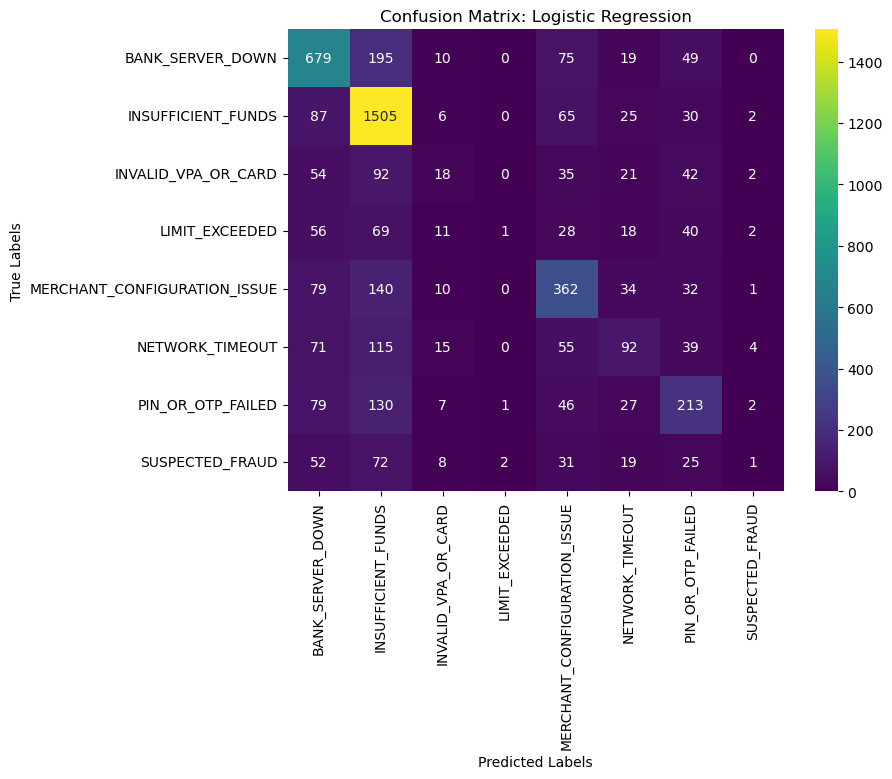

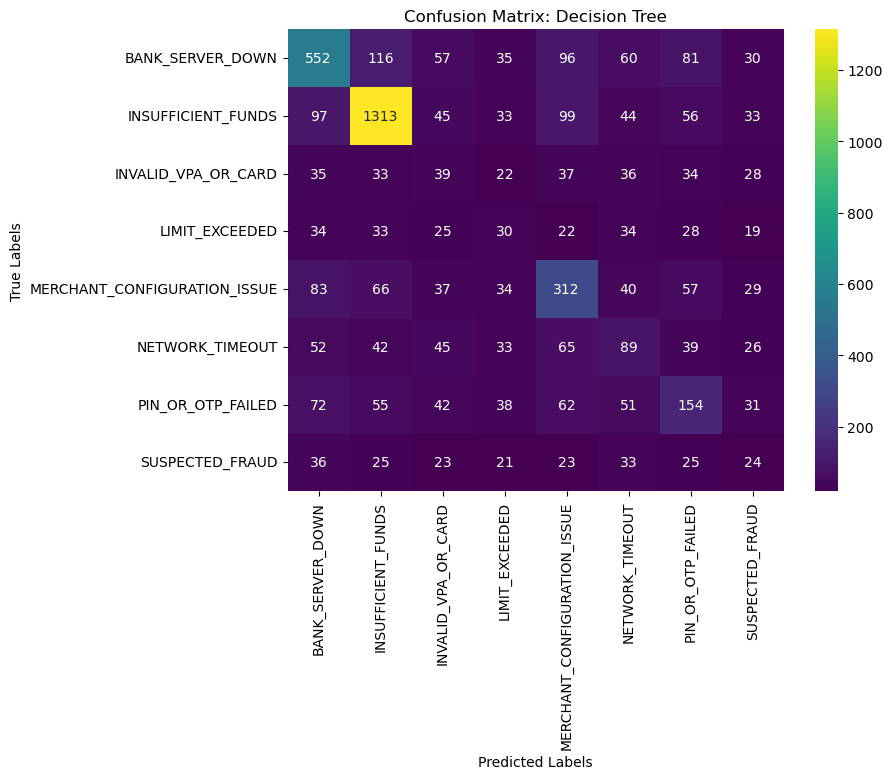

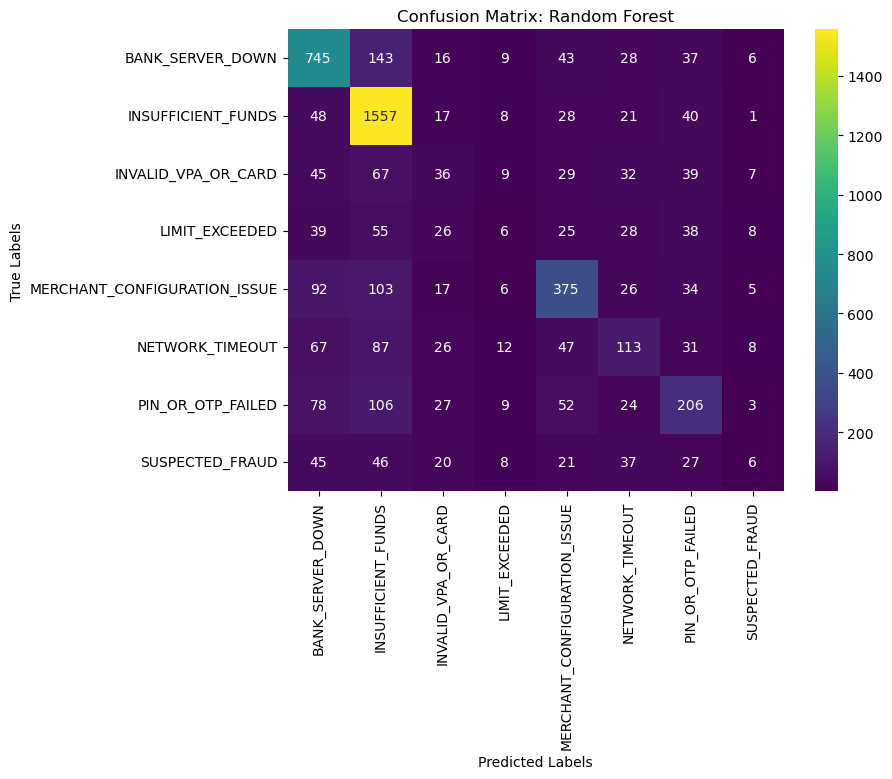

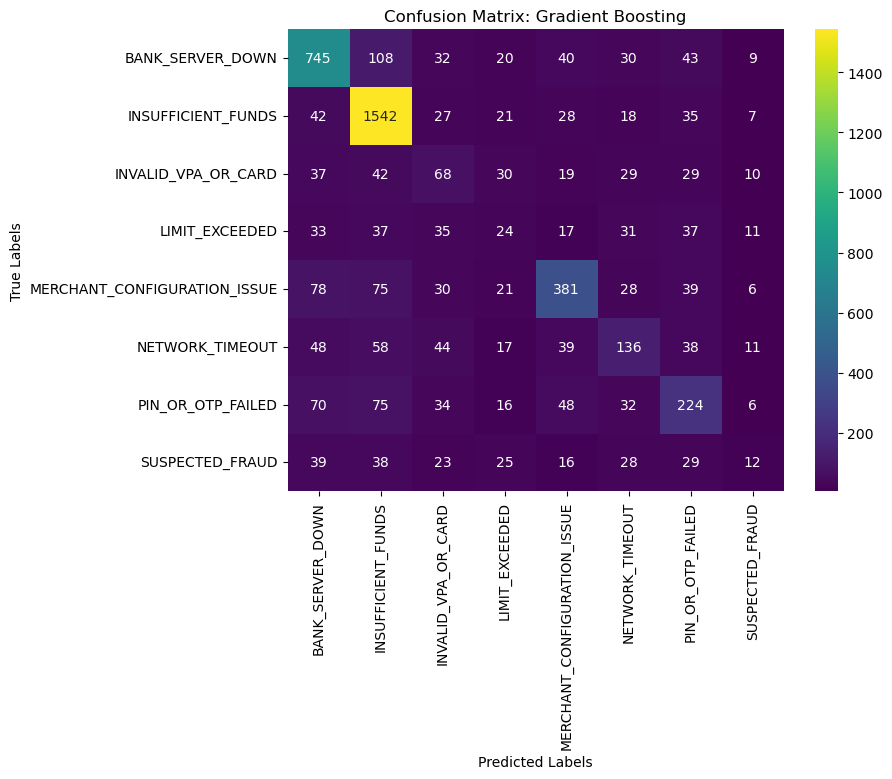

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model_name, true_labels, predicted_labels, class_names):
    cm = confusion_matrix(true_labels, predicted_labels)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

class_names = sorted(set(y_test))  
plot_confusion_matrix("Logistic Regression", y_test, y_pred_lr, class_names)
plot_confusion_matrix("Decision Tree", y_test, y_pred_dt, class_names)
plot_confusion_matrix("Random Forest", y_test, y_pred_rf, class_names)
plot_confusion_matrix("Gradient Boosting", y_test, y_pred_gb, class_names)